In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
nat_gas = pd.read_csv('Nat_Gas.csv')

In [3]:
nat_gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Dates   48 non-null     object 
 1   Prices  48 non-null     float64
dtypes: float64(1), object(1)
memory usage: 900.0+ bytes


In [4]:
nat_gas['Dates'] = pd.to_datetime(nat_gas['Dates'], format='%m/%d/%y')

In [5]:
nat_gas = nat_gas.set_index('Dates')

In [6]:
nat_gas_sort = nat_gas.sort_index()
nat_gas_sort

,Prices
Dates,
2020-10-31,10.10
2020-11-30,10.30
2020-12-31,11.00
2021-01-31,10.90
2021-02-28,10.90
2021-03-31,10.90
2021-04-30,10.40
2021-05-31,9.84
2021-06-30,10.00


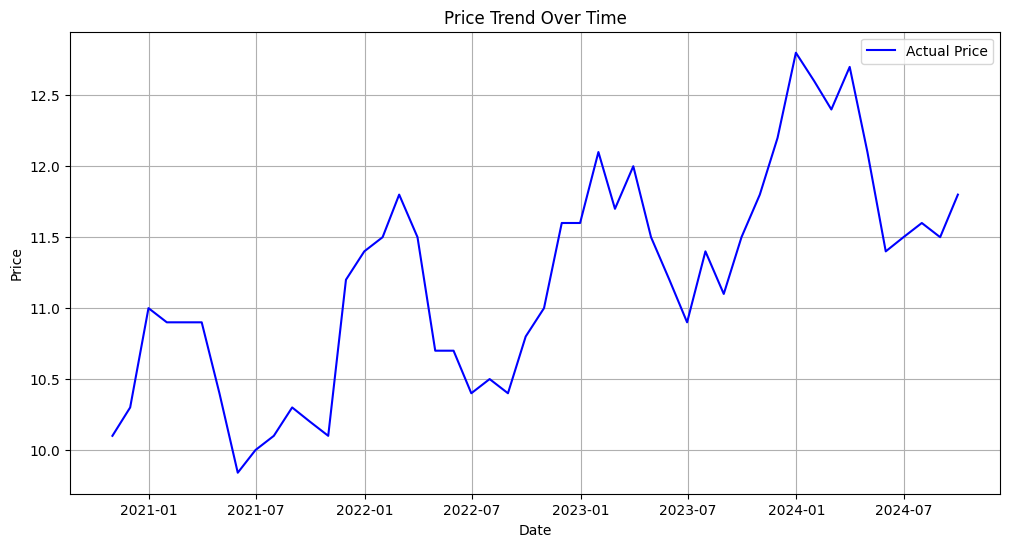

In [8]:
# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(nat_gas.index, nat_gas['Prices'], label='Actual Price', color='blue')

# Add titles and labels
plt.title('Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
PRICE_COL = 'Prices'

def get_price_estimate(df_historical, input_date_str):
    """
    Estimates the natural gas price for any date using a SARIMA model 
    trained on the historical data.

    Args:
        df_historical (pd.DataFrame): DataFrame with 'Date' as index and a price column.
        input_date_str (str): The date to estimate the price for (e.g., '2026-10-31').

    Returns:
        float: The estimated price for the input date.
    """
    # 1. Set up the forecast horizon (1 year from the last date)
    last_historical_date = df_historical.index[-1]
    forecast_end_date = last_historical_date + pd.DateOffset(years=1)
    
    # Ensure the input date is a datetime object
    try:
        target_date = pd.to_datetime(input_date_str)
    except ValueError:
        return "Error: Invalid date format. Use 'YYYY-MM-DD'."

    if target_date > forecast_end_date:
        return (f"Error: Target date is outside the 1-year extrapolation horizon. "
                f"Max forecast date is {forecast_end_date.strftime('%Y-%m-%d')}.")

    print("--- Training SARIMA Model ---")
    
    # 2. SARIMA Model Training
    # The parameters (1, 1, 1)x(0, 1, 1, 12) are a common starting point for 
    # monthly or daily time series with yearly seasonality (12 periods).
    try:
        model = SARIMAX(
            df_historical[PRICE_COL],
            order=(1, 1, 1),             # Non-seasonal parameters (p, d, q)
            seasonal_order=(0, 1, 1, 12), # Seasonal parameters (P, D, Q, S)
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        model_fit = model.fit(disp=False)
        print("SARIMA Model Trained Successfully.")
    except Exception as e:
        return f"Error training SARIMA model: {e}"

    # 3. Estimation/Forecasting
    
    # Create an index spanning from the start of the historical data to the 1-year future date
    full_index = pd.date_range(start=df_historical.index[0], end=forecast_end_date, freq=df_historical.index.freq)

    # The prediction is performed over the full index
    predictions = model_fit.predict(start=full_index.min(), end=full_index.max())
    
    # Find the estimate for the specific input date
    # Use .asof() to get the price at or immediately before the target date
    estimated_price = predictions.asof(target_date)

    return estimated_price

In [10]:
# Define Input Date
input_date = '2025-05-15' # A future date within 1 year


# Get Estimate
estimate = get_price_estimate(nat_gas, input_date)

--- Training SARIMA Model ---
SARIMA Model Trained Successfully.


473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [11]:
# Display Results
print("\n" + "="*40)
print(f"Estimation Date: {input_date}")
print(f"Estimated Price: ${estimate:,.2f}")
print("="*40)


Estimation Date: 2025-05-15
Estimated Price: $12.42
